# STEP 1 — BUSINESS UNDERSTANDING

Problem Statement:
Customer churn tinggi sehingga revenue menurun.

Business Objective:
Memprediksi customer yang berpotensi churn.

KPI:
- Accuracy ≥ 85%
- Recall ≥ 80%
- Penurunan churn ≥ 10%

# STEP 2 — IMPORT LIBRARY

In [4]:
!pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 3.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.0 MB 2.1 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.0 MB 2.1 MB/s eta 0:00:04
   --------- ------------------------------ 1.8/8.0 MB 1.9 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.0 MB 1.8 MB/s eta 0:00:04
   ------------- -------------------------- 2.6/8.0 MB 1.8 MB/s eta 0:00:03
   ----------------- ---------------------- 3.4/8.0 MB 2.2 MB/s eta 0:00:03
   ------------------ --------------------- 3.7/8.0 MB 2.0 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.0 MB 1.9 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.0 MB 1.9 MB/s eta 0:00:03
   ---------------------- -------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# STEP 3 — LOAD DATA

In [2]:
df = pd.read_csv("cc.csv")

df.head()

,CustomerID,Age,Gender,MonthlyCharge,ContractType,InternetService,Tenure,Churn
0,1,56,Male,621923,Month-to-month,Fiber,6,Yes
1,2,46,Female,649384,Two year,Fiber,56,Yes
2,3,32,Male,358099,Month-to-month,DSL,19,No
3,4,25,Male,257561,One year,Fiber,37,Yes
4,5,38,Male,717010,Month-to-month,Fiber,58,No


# STEP 4 — DATA UNDERSTANDING

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerID       500 non-null    int64
 1   Age              500 non-null    int64
 2   Gender           500 non-null    str  
 3   MonthlyCharge    500 non-null    int64
 4   ContractType     500 non-null    str  
 5   InternetService  500 non-null    str  
 6   Tenure           500 non-null    int64
 7   Churn            500 non-null    str  
dtypes: int64(4), str(4)
memory usage: 31.4 KB


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerID       500 non-null    int64
 1   Age              500 non-null    int64
 2   Gender           500 non-null    str  
 3   MonthlyCharge    500 non-null    int64
 4   ContractType     500 non-null    str  
 5   InternetService  500 non-null    str  
 6   Tenure           500 non-null    int64
 7   Churn            500 non-null    str  
dtypes: int64(4), str(4)
memory usage: 31.4 KB


In [8]:
df['Churn'].value_counts()

Churn
No     291
Yes    209
Name: count, dtype: int64

# STEP 5 — VISUALISASI

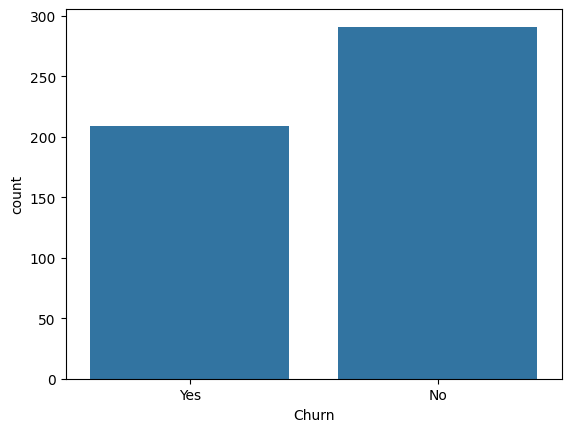

In [9]:
# Distribusi Churn

sns.countplot(x='Churn', data=df)
plt.show()

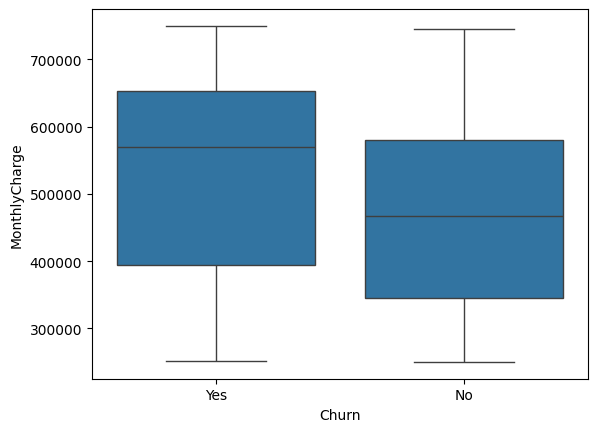

In [10]:
# MonthlyCharge vs Churn
sns.boxplot(x='Churn', y='MonthlyCharge', data=df)
plt.show()

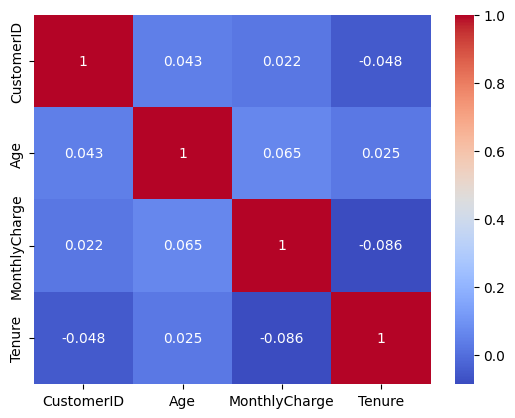

In [12]:
# Heatmap Korelasi
df_numeric = df.select_dtypes(include=np.number)
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

# STEP 6 — DATA CLEANING


In [16]:
# Cek Missing Value
df.isnull().sum()

CustomerID         0
Age                0
Gender             0
MonthlyCharge      0
ContractType       0
InternetService    0
Tenure             0
Churn              0
dtype: int64

In [17]:
# Hapus duplikat
df.drop_duplicates(inplace=True)

In [18]:
# Encoding Categori
le = LabelEncoder()

for col in ['Gender', 'ContractType', 'InternetService', 'Churn']:
    df[col] = le.fit_transform(df[col])

In [19]:
le

LabelEncoder()

# STEP 7 — FEATURE ENGINEERING

In [21]:
# kolom baru 
df['Charge_per_Tenure'] = df['MonthlyCharge'] / df['Tenure']

In [22]:
df

,CustomerID,Age,Gender,MonthlyCharge,ContractType,InternetService,Tenure,Churn,Charge_per_Tenure
0,1,56,1,621923,0,1,6,1,103653.833333
1,2,46,0,649384,2,1,56,1,11596.142857
2,3,32,1,358099,0,0,19,0,18847.315789
3,4,25,1,257561,1,1,37,1,6961.108108
4,5,38,1,717010,0,1,58,0,12362.241379
...,...,...,...,...,...,...,...,...,...
495,496,56,0,353145,1,0,53,1,6663.113208
496,497,49,0,396430,1,0,53,0,7479.811321
497,498,41,1,480785,0,0,46,1,10451.847826
498,499,40,1,344914,2,0,52,0,6632.961538


In [23]:
# Grouping Tenure
df['Tenure_Group'] = pd.cut(df['Tenure'],
                            bins=[0,12,24,60],
                            labels=[0,1,2])

In [24]:
df

,CustomerID,Age,Gender,MonthlyCharge,ContractType,InternetService,Tenure,Churn,Charge_per_Tenure,Tenure_Group
0,1,56,1,621923,0,1,6,1,103653.833333,0
1,2,46,0,649384,2,1,56,1,11596.142857,2
2,3,32,1,358099,0,0,19,0,18847.315789,1
3,4,25,1,257561,1,1,37,1,6961.108108,2
4,5,38,1,717010,0,1,58,0,12362.241379,2
...,...,...,...,...,...,...,...,...,...,...
495,496,56,0,353145,1,0,53,1,6663.113208,2
496,497,49,0,396430,1,0,53,0,7479.811321,2
497,498,41,1,480785,0,0,46,1,10451.847826,2
498,499,40,1,344914,2,0,52,0,6632.961538,2


# STEP 8 — SPLIT FEATURE & TARGET

In [25]:
# Split feature and target 

X = df.drop(['CustomerID','Churn'], axis=1)
y = df['Churn']

# STEP 9 — TRAIN TEST SPLIT

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# STEP 10 — SCALING

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# STEP 11 — MODELING (LOGISTIC)

In [28]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.6466666666666666
[[61 19]
 [34 36]]
              precision    recall  f1-score   support

           0       0.64      0.76      0.70        80
           1       0.65      0.51      0.58        70

    accuracy                           0.65       150
   macro avg       0.65      0.64      0.64       150
weighted avg       0.65      0.65      0.64       150



# STEP 12 — MODELING (DECISION TREE)

In [29]:
dt_model = DecisionTreeClassifier(max_depth=5)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.5933333333333334


# STEP 13 — MODELING (RANDOM FOREST)

In [30]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.6333333333333333


# STEP 14 — CROSS VALIDATION

In [31]:
cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("Mean CV Accuracy:", cv_scores.mean())

Mean CV Accuracy: 0.656


# STEP 15 — HYPERPARAMETER TUNING

In [32]:
param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [None,5,10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': 5, 'n_estimators': 200}
Best Score: 0.7058158954710679


# STEP 16 — REGRESSION VERSION

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_reg = df.drop(['CustomerID','MonthlyCharge'], axis=1)
y_reg = df['MonthlyCharge']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

model_reg = LinearRegression()
model_reg.fit(X_train_r, y_train_r)

y_pred_r = model_reg.predict(X_test_r)

print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("MSE:", mean_squared_error(y_test_r, y_pred_r))
print("R2:", r2_score(y_test_r, y_pred_r))

MAE: 121392.51970152385
MSE: 20208970318.4084
R2: 0.050498994767907646


# STEP 17 — CLUSTERING VERSION

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [35]:
X_cluster = df[['Age','MonthlyCharge','Tenure']]

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_cluster)

labels = kmeans.labels_

print("Silhouette Score:", silhouette_score(X_cluster, labels))

Silhouette Score: 0.5786134926715769


# STEP 18 — JAWABAN LISAN SIAP HAFALAN

Kenapa pilih Random Forest?
Karena mampu menangani hubungan non-linear dan lebih stabil terhadap overfitting.

Kenapa scaling perlu?
Agar semua fitur berada dalam skala yang sama sehingga model berbasis jarak bekerja optimal.

Kenapa recall penting?
Karena kita ingin mendeteksi sebanyak mungkin customer churn agar tidak kehilangan revenue.

Jika model jelek?
1. Cek kualitas data
2. Tambah fitur
3. Coba model lain
4. Tuning hyperparameter